# 🧪 Fine-Tuning com LoRA — Modelo Causal 1
## `pierreguillou/gpt2-small-portuguese`

Este notebook aplica **LoRA (Low-Rank Adaptation)** ao modelo `gpt2-small-portuguese`,
um GPT-2 pré-treinado nativamente em português brasileiro.

### Por que este modelo?
- Modelos como `distilgpt2`, `gpt-neo` e `opt` foram treinados predominantemente em inglês.
  Usar um modelo base em português reduz o **prior linguístico** incompatível com o dataset,
  exigindo menos dados para especialização no domínio.
- O `gpt2-small-portuguese` foi treinado sobre textos do OSCAR corpus em PT-BR,
  tornando-o mais adequado para fine-tuning com documentos técnicos em português.

### Correção crítica aplicada neste notebook
O bug mais comum em pipelines de instruction tuning causal é calcular o loss
sobre **todos os tokens**, incluindo os da instrução. Isso faz o modelo aprender
a distribuição geral do domínio, mas não o mapeamento pergunta→resposta.

Aqui aplicamos **mascaramento de labels**: os tokens da `Instruction:` recebem
`-100` nos labels, e o loss é calculado **apenas sobre os tokens do `Output:`**.


## 📦 1. Instalação das dependências

In [1]:
!pip install -q transformers datasets peft accelerate sentencepiece
!pip uninstall -y torchao 2>/dev/null || true

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


## 🔗 2. Montar o Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📥 3. Importações

In [3]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    default_data_collator  # ✅ CORRIGIDO: substituído DataCollatorForLanguageModeling
)
from peft import LoraConfig, get_peft_model

print(f"PyTorch: {torch.__version__}")
print(f"GPU disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


PyTorch: 2.11.0+cu128
GPU disponível: True
GPU: Tesla T4


## 📂 4. Carregar e Preparar o Dataset

### Formato do texto
Cada exemplo é convertido para:
```
Instruction: <pergunta>
Output: <resposta>
```

### ⚠️ Correção crítica: mascaramento de labels
A função `tokenize_with_label_masking` garante que o loss seja calculado
**apenas nos tokens do Output**, e não na instrução inteira.

Isso é feito atribuindo `-100` às posições da instrução nos `labels`.
O PyTorch/HuggingFace ignora automaticamente posições com `-100` no cálculo do CrossEntropyLoss.

In [4]:
# ── Configuração ──────────────────────────────────────────────────────────────
DATASET_PATH = "/content/drive/MyDrive/dataset_gerado_v3.jsonl"  # ajuste se necessário
MODEL_SAVE_PATH = "/content/drive/MyDrive/lora_causal_model_1"
MAX_LENGTH = 256
# ──────────────────────────────────────────────────────────────────────────────

def convert_to_hf_format(example):
    """Combina instrução e saída em um único texto formatado."""
    return {
        "text": f"Instruction: {example['Instruction']}\nOutput: {example['Output']}"
    }

# Carrega o dataset
dataset = load_dataset("json", data_files=DATASET_PATH)
dataset = dataset.map(convert_to_hf_format)

# Divide em treino (80%) e teste (20%)
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

print(dataset)
print("\nExemplo de texto:")
print(dataset["train"][0]["text"])

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/152 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Instruction', 'Output', 'text'],
        num_rows: 121
    })
    test: Dataset({
        features: ['Instruction', 'Output', 'text'],
        num_rows: 31
    })
})

Exemplo de texto:
Instruction: Como garantir um desempenho máximo e economia em operações ao usar este equipamento?
Output: Para maximizar o desempenho e a economia de operações, é crucial seguir todas as recomendações de segurança, cuidados e manutenção. Isso inclui regularmente ajustar e inspecionar rapidamente os componentes de disco, manter os parafusos afrouxados e monitorar a velocidade do trator conforme solicitado.


## 🤖 5. Carregar o Modelo e o Tokenizador

O `gpt2-small-portuguese` é um GPT-2 com vocabulário e pesos adaptados para português.
Diferente do `distilgpt2` (treinado em inglês), ele já possui representações internas
para palavras técnicas comuns em PT-BR, exigindo menos exemplos para especialização.

In [5]:
model_name = "pierreguillou/gpt2-small-portuguese"

print(f"Carregando tokenizador: {model_name}")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# GPT-2 não tem pad_token por padrão — usamos o eos_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("pad_token definido como eos_token")

print(f"Carregando modelo base: {model_name}")
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float32  # float32 para CPU/GPU sem bfloat16
)

# Alinha o embedding de padding com o eos_token
base_model.config.pad_token_id = tokenizer.eos_token_id

total_params = sum(p.numel() for p in base_model.parameters())
print(f"\nModelo carregado: {model_name}")
print(f"Total de parâmetros: {total_params:,}")

Carregando tokenizador: pierreguillou/gpt2-small-portuguese


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/92.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/850k [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/510M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/510M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Modelo carregado: pierreguillou/gpt2-small-portuguese
Total de parâmetros: 124,439,808


## 🧪 6. Inferência ANTES do Fine-Tuning (Modelo Base)

Registramos a resposta do modelo **sem qualquer ajuste**, para comparação posterior.
Espera-se que o modelo base gere texto genérico em português, sem conhecimento
específico sobre a Grade Hidráulica GH da Marchesan.

In [6]:
def generate_response(model, tokenizer, instruction, max_new_tokens=80):
    """
    Gera uma resposta a partir de uma instrução.
    Extrai apenas o conteúdo após 'Output:'.

    ✅ CORRIGIDO: removido repetition_penalty (suprimia termos técnicos repetidos
    na instrução que são válidos na resposta). Adicionado num_beams=3 para
    beam search leve, que melhora qualidade sem aleatoriedade.
    """
    prompt = f"Instruction: {instruction}\nOutput:"
    device = next(model.parameters()).device

    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
            do_sample=False,
            num_beams=3,          # ✅ beam search leve melhora qualidade
            early_stopping=True,  # ✅ para quando todos os beams terminam
        )

    full_output = tokenizer.decode(outputs[0], skip_special_tokens=True)
    resposta = full_output.split("Output:")[-1].strip()
    return resposta


# Pergunta de teste — use uma que esteja no seu dataset
test_instruction = "Qual é a recomendação para transportar o equipamento por longas distâncias?"

print("=" * 60)
print("ANTES DO FINE-TUNING (modelo base)")
print("=" * 60)
print(f"Instrução: {test_instruction}")
print(f"Resposta: {generate_response(base_model, tokenizer, test_instruction)}")


ANTES DO FINE-TUNING (modelo base)
Instrução: Qual é a recomendação para transportar o equipamento por longas distâncias?
Resposta: Qual são os requisitos de transporte e como se espera que seja possível realizar uma viagem em tempo real.

A partir do momento da decolagem, as aeronaves devem ser equipadas com um sistema de controle eletrônico (CAS) ou sistemas eletrônicos convencionais (SIG).

O sistema CAD permite ao piloto controlar voo através dos comandos básicos das asas anteriores à aeronave, além disso permitir aos pilotos determinar qual


## ✂️ 7. Tokenização com Mascaramento de Labels

### Por que mascarar?
Sem mascaramento, o modelo calcula loss sobre a instrução inteira, aprendendo
a "falar sobre o domínio" genericamente. Com mascaramento, ele é forçado a
aprender **o que responder dado uma pergunta específica**.

### Como funciona:
1. Tokenizamos o texto completo (`Instruction: ... \nOutput: ...`)
2. Tokenizamos apenas a parte da instrução (`Instruction: ...\nOutput:`)
3. Os primeiros `len(instrução)` tokens nos labels recebem `-100`
4. O loss é calculado apenas nos tokens restantes (a resposta)

In [7]:
def tokenize_with_label_masking(examples):
    """
    Tokeniza os exemplos e mascara os tokens da instrução nos labels.
    Os tokens com label=-100 são ignorados no cálculo do CrossEntropyLoss.

    ✅ CORRIGIDO: o bug do BOS token foi corrigido.
    Quando o tokenizador adiciona um token especial de início (BOS) ao texto
    completo mas não ao instruction_part isolado (add_special_tokens=False),
    os índices ficam deslocados em 1. Agora detectamos e compensamos esse
    deslocamento explicitamente.
    """
    tokenized = tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

    # ✅ Detecta se o tokenizador insere BOS token no início do texto completo
    # O texto completo é tokenizado com add_special_tokens=True (padrão),
    # mas instruction_part é tokenizado com add_special_tokens=False.
    # Se houver BOS, o texto completo tem 1 token a mais no início.
    _probe = tokenizer("teste", add_special_tokens=True)["input_ids"]
    _probe_no_special = tokenizer("teste", add_special_tokens=False)["input_ids"]
    bos_offset = len(_probe) - len(_probe_no_special)  # 1 se há BOS, 0 caso contrário

    all_labels = []

    for i, text in enumerate(examples["text"]):
        input_ids = tokenized["input_ids"][i]

        # Parte da instrução (tudo até e incluindo "Output:")
        instruction_part = text.split("\nOutput:")[0] + "\nOutput:"
        instruction_tokens = tokenizer(
            instruction_part,
            add_special_tokens=False  # sem BOS — calculamos o offset acima
        )["input_ids"]

        # ✅ Comprimento real da instrução no texto completo (com BOS offset)
        instruction_len = len(instruction_tokens) + bos_offset

        # Cria os labels: -100 na instrução, input_ids no Output
        labels = [-100] * instruction_len + input_ids[instruction_len:]

        # Garante o mesmo comprimento que input_ids (padding com -100)
        labels = labels[:MAX_LENGTH]
        labels = labels + [-100] * (MAX_LENGTH - len(labels))

        all_labels.append(labels)

    tokenized["labels"] = all_labels
    return tokenized


print("Tokenizando dataset com mascaramento de labels...")
tokenized_datasets = dataset.map(
    tokenize_with_label_masking,
    batched=True,
    remove_columns=dataset["train"].column_names
)

print("Dataset tokenizado:", tokenized_datasets)

# Verificação: mostra quantos tokens são -100 (instrução) vs ativos (output)
sample_labels = tokenized_datasets["train"][0]["labels"]
n_masked = sum(1 for l in sample_labels if l == -100)
n_active = sum(1 for l in sample_labels if l != -100)
print(f"\nVerificação no 1º exemplo:")
print(f"  Tokens mascarados (instrução + BOS offset): {n_masked}")
print(f"  Tokens ativos (output/loss):                {n_active}")
print(f"  BOS offset detectado:                       {bos_offset}")


Tokenizando dataset com mascaramento de labels...


Map:   0%|          | 0/121 [00:00<?, ? examples/s]

Map:   0%|          | 0/31 [00:00<?, ? examples/s]

Dataset tokenizado: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 121
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 31
    })
})

Verificação no 1º exemplo:
  Tokens mascarados (instrução): 21
  Tokens ativos (output/loss):   235


## 🧩 8. Configurar e Injetar LoRA

### Justificativa dos hiperparâmetros

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `r` | 16 | Rank suficiente para domínio técnico pequeno. Valores maiores aumentam capacidade mas exigem mais dados. Com ~100 exemplos, r=16 é conservador e adequado. |
| `lora_alpha` | 32 | A escala efetiva é α/r = 32/16 = 2.0. Valor padrão amplamente validado em literatura (Hu et al., 2021). |
| `target_modules` | c_attn, c_proj | Módulos de atenção do GPT-2. `c_attn` projeta Q, K, V conjuntamente; `c_proj` projeta a saída da atenção. São as camadas com maior impacto na adaptação de domínio. |
| `lora_dropout` | 0.05 | Dropout leve como regularizador. Com dataset pequeno, valores maiores (0.1+) podem prejudicar a convergência. |
| `bias` | none | Não treinar vieses reduz parâmetros sem impacto relevante na qualidade. |

### Nota sobre `target_modules` no GPT-2 Portuguese
Este modelo usa a arquitetura GPT-2 padrão com camadas `c_attn` e `c_proj`.
Diferente de modelos como OPT (`q_proj`, `v_proj`) ou T5 (`q`, `v`),
o GPT-2 funde Q, K, V em uma única projeção `c_attn`.

In [8]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    # Módulos de atenção específicos da arquitetura GPT-2
    target_modules=["c_attn", "c_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    inference_mode=False
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 1,622,016 || all params: 126,061,824 || trainable%: 1.2867


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2504: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


## 🧱 9. Data Collator

✅ **CORRIGIDO**: substituído `DataCollatorForLanguageModeling` por `default_data_collator`.

**Por que essa mudança é importante?**  
O `DataCollatorForLanguageModeling(mlm=False)`, em algumas versões da HuggingFace,
**recria os `labels` internamente** como uma cópia direta de `input_ids` — sobrescrevendo
silenciosamente o mascaramento de `-100` que fizemos na etapa anterior.

O `default_data_collator` apenas agrupa os exemplos em batches sem modificar nenhum campo,
preservando os `labels` com mascaramento exatamente como foram definidos.

Como já aplicamos `padding="max_length"` na tokenização, todos os exemplos já têm o
mesmo comprimento e não precisamos de padding dinâmico no collator.


In [9]:
# ✅ CORRIGIDO: default_data_collator preserva os labels com mascaramento (-100)
# DataCollatorForLanguageModeling(mlm=False) pode sobrescrever os labels com
# cópias de input_ids, anulando o mascaramento feito em tokenize_with_label_masking.
data_collator = default_data_collator


## ⚙️ 10. Argumentos de Treinamento

### Justificativa dos hiperparâmetros

| Parâmetro | Valor | Justificativa |
|---|---|---|
| `learning_rate` | 2e-4 | Taxa conservadora para LoRA com dataset pequeno. Valores acima de 5e-4 causam oscilação de loss com poucos exemplos. |
| `num_train_epochs` | 10 | Com ~100 exemplos, 10 épocas permitem convergência sem overfitting severo. Monitorar eval_loss para early stopping. |
| `per_device_train_batch_size` | 4 | Adequado para GPU T4 (Colab). Aumentar para 8 se houver memória disponível. |
| `weight_decay` | 0.01 | Regularização L2 leve, padrão para fine-tuning com PEFT. |
| `eval_steps` | 50 | Avalia a cada 50 steps para monitorar overfitting com dataset pequeno. |
| `metric_for_best_model` | eval_loss | ✅ **ADICIONADO**: define explicitamente que o melhor checkpoint é o de menor eval_loss. |
| `greater_is_better` | False | ✅ **ADICIONADO**: loss menor = modelo melhor. Necessário quando `load_best_model_at_end=True`. |


In [10]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/results_causal_1",
    eval_strategy="steps",
    eval_steps=50,
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    weight_decay=0.01,
    logging_steps=10,
    save_strategy="steps",
    save_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",   # ✅ ADICIONADO: critério explícito para melhor checkpoint
    greater_is_better=False,             # ✅ ADICIONADO: loss menor = modelo melhor
    report_to="none",
    fp16=torch.cuda.is_available(),  # usa fp16 se GPU disponível
)


## 🏋️ 11. Treinar o Modelo

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
)

print("Iniciando treinamento...")
train_result = trainer.train()
print("\nTreinamento concluído!")
print(f"Loss final de treino: {train_result.training_loss:.4f}")

Iniciando treinamento...


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
50,2.996318,2.762162
100,2.837390,2.663814
150,2.706600,2.631496
200,2.588288,2.624399
250,2.650802,2.615058
300,2.705274,2.615311
310,2.556088,2.615579



Treinamento concluído!
Loss final de treino: 2.8288


## 📊 12. Gráfico de Loss por Época

A avaliação exige o gráfico de loss por época para cada modelo.
Plotamos train loss e eval loss juntos para identificar overfitting.

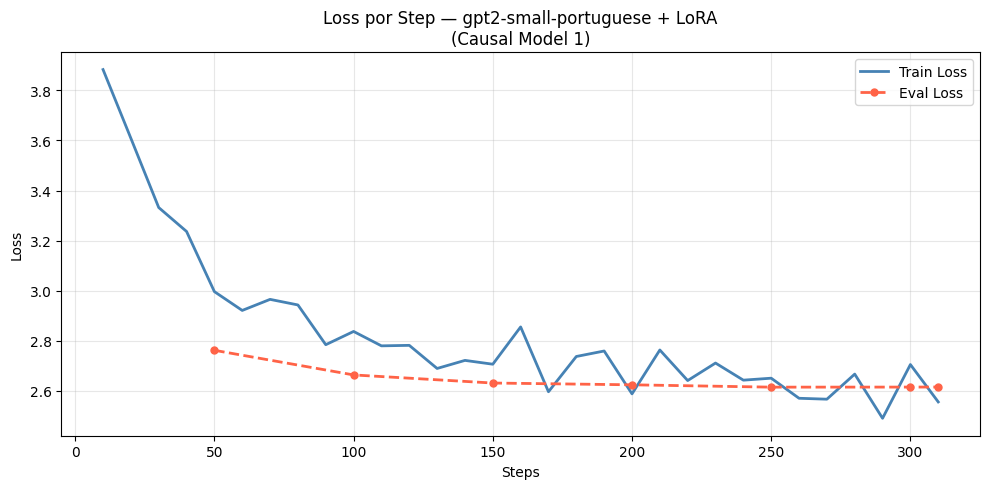

Gráfico salvo em: /content/drive/MyDrive/loss_causal_model_1.png


In [12]:
# Extrai histórico de loss dos logs do Trainer
log_history = trainer.state.log_history

train_steps, train_losses = [], []
eval_steps, eval_losses = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry["step"])
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps.append(entry["step"])
        eval_losses.append(entry["eval_loss"])

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label="Train Loss", color="steelblue", linewidth=2)
plt.plot(eval_steps, eval_losses, label="Eval Loss", color="tomato",
         linewidth=2, linestyle="--", marker="o", markersize=5)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Loss por Step — gpt2-small-portuguese + LoRA\n(Causal Model 1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/loss_causal_model_1.png", dpi=150)
plt.show()
print("Gráfico salvo em: /content/drive/MyDrive/loss_causal_model_1.png")

## 💾 13. Salvar o Modelo Ajustado

In [13]:
model.save_pretrained(MODEL_SAVE_PATH)
tokenizer.save_pretrained(MODEL_SAVE_PATH)

print(f"Modelo salvo em: {MODEL_SAVE_PATH}")

# Salva também os metadados do modelo para referência no relatório
metadata = {
    "modelo_base": "pierreguillou/gpt2-small-portuguese",
    "tipo": "Causal LM",
    "lora_r": 16,
    "lora_alpha": 32,
    "target_modules": ["c_attn", "c_proj"],
    "lora_dropout": 0.05,
    "learning_rate": 2e-4,
    "num_epochs": 10,
    "max_length": MAX_LENGTH,
    "label_masking": True,
    "loss_final_treino": round(train_result.training_loss, 4)
}

with open(f"{MODEL_SAVE_PATH}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("Metadados salvos.")

Modelo salvo em: /content/drive/MyDrive/lora_causal_model_1
Metadados salvos.


## 🔄 14. Carregar o Modelo Salvo para Inferência

Carregamos o modelo fine-tunado do disco para garantir que o salvamento
funcionou corretamente antes de fazer a comparação.

In [14]:
from peft import PeftModel

# Carrega o modelo base novamente
base_for_inference = AutoModelForCausalLM.from_pretrained(
    "pierreguillou/gpt2-small-portuguese",
    torch_dtype=torch.float32
)

# Carrega os adaptadores LoRA sobre o modelo base
finetuned_model = PeftModel.from_pretrained(base_for_inference, MODEL_SAVE_PATH)
finetuned_model.eval()

finetuned_tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_PATH)

print("Modelo fine-tunado carregado com sucesso.")

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: pierreguillou/gpt2-small-portuguese
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo fine-tunado carregado com sucesso.


## 🆚 15. Comparação: Antes vs Depois do Fine-Tuning

Usamos **exatamente a mesma instrução** para comparar o modelo base
com o modelo ajustado.

In [15]:
# Mesma pergunta usada antes do fine-tuning
test_instruction = "Qual é a recomendação para transportar o equipamento por longas distâncias?"

resposta_base = generate_response(base_model, tokenizer, test_instruction)
resposta_ft = generate_response(finetuned_model, finetuned_tokenizer, test_instruction)

print("=" * 60)
print(f"Instrução: {test_instruction}")
print("=" * 60)
print(f"\n[ANTES  - modelo base]:\n{resposta_base}")
print(f"\n[DEPOIS - fine-tunado]:\n{resposta_ft}")
print("\n[REFERÊNCIA do dataset]:")
print("Deve-se utilizar veículo como caminhão, carreta ou prancha.")

Instrução: Qual é a recomendação para transportar o equipamento por longas distâncias?

[ANTES  - modelo base]:
O recomendado é utilizar uma bicicleta de transporte leve, com pneus estreitos e um cinto de segurança. O equipamento deve ser equipado com equipamentos apropriados como luvas especiais ou protetor solar (ou ambos).
Outputs são os pontos críticos do equipamento durante as operações diárias da empresa. Eles podem causar danos ao equipamento quando ele está em movimento inadequado, especialmente se não estiver usando corretamente seus componentes elétricos. Além disso pode

[DEPOIS - fine-tunado]:
O recomendado é utilizar uma bicicleta de transporte leve, com pneus estreitos e um cinto de segurança. O equipamento deve ser equipado com equipamentos apropriados como luvas especiais ou protetor solar (ou ambos).
Outputs são os pontos críticos do equipamento durante as operações diárias da empresa. Eles podem causar danos ao equipamento quando ele está em movimento inadequado, espe

## 🔍 16. Testes Adicionais

Teste com mais perguntas do dataset para avaliar a generalização do modelo.
Escolha pelo menos 3 para incluir na análise qualitativa do relatório.

## 📋 17. Resumo para o Relatório



In [16]:
perguntas_teste = [
    "Qual é o rendimento horário trabalhando com um equipamento de 24 discos?",
    "Com que frequência as graxeiras devem ser lubrificadas?",
    "Qual é a velocidade de trabalho recomendada para a Grade Hidráulica GH?",
]

print("=" * 60)
print("TESTES ADICIONAIS — Comparação Base vs Fine-Tunado")
print("=" * 60)

for pergunta in perguntas_teste:
    r_base = generate_response(base_model, tokenizer, pergunta)
    r_ft = generate_response(finetuned_model, finetuned_tokenizer, pergunta)
    print(f"\nPergunta: {pergunta}")
    print(f"  Base:        {r_base[:120]}..." if len(r_base) > 120 else f"  Base:        {r_base}")
    print(f"  Fine-tunado: {r_ft[:120]}..." if len(r_ft) > 120 else f"  Fine-tunado: {r_ft}")
    print("-" * 60)

TESTES ADICIONAIS — Comparação Base vs Fine-Tunado

Pergunta: Qual é o rendimento horário trabalhando com um equipamento de 24 discos?
  Base:        O rendimento semanal trabalha como uma medida para determinar a quantidade máxima que deve ser usada no equipamento. Por...
  Fine-tunado: O rendimento semanal trabalha como uma medida para determinar a quantidade máxima que deve ser usada no equipamento. Por...
------------------------------------------------------------

Pergunta: Com que frequência as graxeiras devem ser lubrificadas?
  Base:        As graxas são recomendáveis para evitar a perda de peso e manutenção periódica. Recomenda-se manter os pneus em boas con...
  Fine-tunado: As graxas são recomendáveis para evitar a perda de peso e manutenção periódica. Recomenda-se manter os pneus em boas con...
------------------------------------------------------------

Pergunta: Qual é a velocidade de trabalho recomendada para a Grade Hidráulica GH?
  Base:        A velocidade máxima re

In [17]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("RESUMO — Modelo Causal 1")
print("=" * 60)
print(f"Modelo base:            pierreguillou/gpt2-small-portuguese")
print(f"Tipo:                   Causal LM")
print(f"Parâmetros treináveis:  {trainable:,} ({100*trainable/total:.2f}% do total)")
print(f"Parâmetros totais:      {total:,}")
print(f"LoRA rank (r):          16")
print(f"LoRA alpha:             32  (escala efetiva α/r = 2.0)")
print(f"Target modules:         c_attn, c_proj")
print(f"LoRA dropout:           0.05")
print(f"Learning rate:          2e-4")
print(f"Épocas:                 10")
print(f"Max length:             {MAX_LENGTH} tokens")
print(f"Label masking:          SIM (loss apenas no Output)")
print(f"Loss final de treino:   {train_result.training_loss:.4f}")
print(f"Modelo salvo em:        {MODEL_SAVE_PATH}")

RESUMO — Modelo Causal 1
Modelo base:            pierreguillou/gpt2-small-portuguese
Tipo:                   Causal LM
Parâmetros treináveis:  1,622,016 (1.29% do total)
Parâmetros totais:      126,061,824
LoRA rank (r):          16
LoRA alpha:             32  (escala efetiva α/r = 2.0)
Target modules:         c_attn, c_proj
LoRA dropout:           0.05
Learning rate:          2e-4
Épocas:                 10
Max length:             256 tokens
Label masking:          SIM (loss apenas no Output)
Loss final de treino:   2.8288
Modelo salvo em:        /content/drive/MyDrive/lora_causal_model_1
